# Vina Post-processing Visualization

This notebook visualizes the results from Vina docking post-processing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10

# Set plot directory
plot_dir = Path('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/eval/vina_plots')
plot_dir.mkdir(parents=True, exist_ok=True)
print(f"Plot directory: {plot_dir}")

Plot directory: /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/eval/vina_plots


## Load Data

In [2]:
# Load the summary CSV file
csv_file_1 = '/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/eval/vina_post_summary_config01.csv'
df_1 = pd.read_csv(csv_file_1)

print(f"Loaded {len(df_1)} records")
print(f"\nColumns: {df_1.columns.tolist()}")
print(f"\nData shape: {df_1.shape}")
df_1.head()

Loaded 7890 records

Columns: ['complex_id', 'config_num', 'pdb_id', 'ligand_het_id', 'run_id', 'seed', 'vina_score', 'ligand_com_distance', 'ligand_ifp_similarity', 'ligand_rmsd_current_seed', 'ligand_rmsd_avg_all_seeds', 'pose_ifp', 'target_ifp', 'target_pdb_path', 'complex_pdb_path', 'complex_pdb_saved', 'num_receptor_atoms', 'num_ligand_atoms', 'notes']

Data shape: (7890, 19)


,complex_id,config_num,pdb_id,ligand_het_id,run_id,seed,vina_score,ligand_com_distance,ligand_ifp_similarity,ligand_rmsd_current_seed,ligand_rmsd_avg_all_seeds,pose_ifp,target_ifp,target_pdb_path,complex_pdb_path,complex_pdb_saved,num_receptor_atoms,num_ligand_atoms,notes
0,81,1,4ZTR,4RJ,complex_0081_off01,0,-7.785,2.565139,0.0,NaN,0.000431,"{'hbond': {('A', 'ALA', 209), ('A', 'ALA', 195...","{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 214...",/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,True,996,36,OK
1,81,1,4ZTR,4RJ,complex_0081_off01,1,-7.787,2.689259,0.0,0.000425,0.000431,"{'hbond': {('A', 'ALA', 209), ('A', 'ALA', 195...","{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 214...",/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,True,996,36,OK
2,81,1,4ZTR,4RJ,complex_0081_off01,2,-7.786,2.634369,0.0,0.000414,0.000431,"{'hbond': {('A', 'ALA', 209), ('A', 'ALA', 195...","{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 214...",/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,True,996,36,OK
3,81,1,4ZTR,4RJ,complex_0081_off01,3,-7.845,3.193275,0.0,0.000506,0.000431,"{'hbond': {('A', 'ALA', 195), ('A', 'ALA', 145...","{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 214...",/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,True,996,36,OK
4,81,1,4ZTR,4RJ,complex_0081_off01,4,-7.881,3.459263,0.0,0.000385,0.000431,"{'hbond': {('A', 'ALA', 273), ('A', 'ALA', 208...","{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 214...",/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,True,996,36,OK


In [3]:
# Basic statistics
print("Data Summary:")
print(f"Total records: {len(df_1)}")
print(f"Unique complexes: {df_1['complex_id'].nunique()}")
print(f"Unique ligands: {df_1['ligand_het_id'].nunique()}")
print(f"Successful PDB saves: {df_1['complex_pdb_saved'].sum()}")
print(f"\nNumeric columns statistics:")
df_1.describe()

Data Summary:
Total records: 7890
Unique complexes: 1578
Unique ligands: 1352
Successful PDB saves: 6505

Numeric columns statistics:


,complex_id,config_num,seed,vina_score,ligand_com_distance,ligand_ifp_similarity,ligand_rmsd_current_seed,ligand_rmsd_avg_all_seeds,num_receptor_atoms,num_ligand_atoms
count,7890.000000,7890.0,7890.000000,6505.000000,6395.000000,6395.000000,5.204000e+03,6505.000000,7890.000000,7890.000000
mean,4323.595691,1.0,2.000000,-7.043159,8.746901,0.058184,1.916481e-01,0.192509,1735.340938,26.614068
std,2000.677665,0.0,1.414303,5.601583,2.896532,0.158909,3.190282e-01,0.274901,1746.911209,15.090885
min,81.000000,1.0,0.000000,-206.323000,0.898313,0.000000,7.716517e-07,0.000017,0.000000,0.000000
25%,2836.000000,1.0,1.000000,-7.798000,6.597053,0.000000,3.875095e-04,0.000384,980.000000,15.000000
50%,4592.500000,1.0,2.000000,-7.370000,9.088358,0.000000,1.595312e-02,0.021077,1198.000000,32.000000
75%,6080.000000,1.0,3.000000,-6.119000,10.814445,0.000000,2.967016e-01,0.357768,2208.000000,40.000000
max,7275.000000,1.0,4.000000,-3.222000,19.864763,1.000000,2.566213e+00,1.691753,18960.000000,78.000000


In [9]:
def load_and_summarize(csv_path):
    df = pd.read_csv(csv_path)
    print("=== Data Summary ===")
    print(f"Total records: {len(df)}")
    print(f"Unique complexes: {df['complex_id'].nunique()}")
    print(f"Unique ligands: {df['ligand_het_id'].nunique()}")
    print(f"Successful PDB saves: {df['complex_pdb_saved'].sum()}")
    print("")
    return df

base_dir = Path('/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/eval')
print("Config 01 Vina Post-processing Summary")
csv_file_1 = base_dir / 'vina_post_summary_config01.csv'
df_1 = load_and_summarize(csv_file_1)

print("Config 02 Vina Post-processing Summary")
csv_file_2 = base_dir / 'vina_post_summary_config02.csv'
df_2 = load_and_summarize(csv_file_2)

print("Config 03 Vina Post-processing Summary")
csv_file_3 = base_dir / 'vina_post_summary_config03.csv'
df_3 = load_and_summarize(csv_file_3)

df = pd.concat(
    [df_1.assign(config=1), df_2.assign(config=2), df_3.assign(config=3)], 
    ignore_index=True
)
print("Combined Data Summary:")
print(f"Total records: {len(df)}")
print(f"Unique complexes: {df['complex_id'].nunique()}")
print(f"Unique ligands: {df['ligand_het_id'].nunique()}")
print(f"Successful PDB saves: {df['complex_pdb_saved'].sum()}")
print(f"\nNumeric columns statistics:")
df.describe()

Config 01 Vina Post-processing Summary
=== Data Summary ===
Total records: 7890
Unique complexes: 1578
Unique ligands: 1352
Successful PDB saves: 6505

Config 02 Vina Post-processing Summary
=== Data Summary ===
Total records: 7885
Unique complexes: 1577
Unique ligands: 1351
Successful PDB saves: 6765

Config 03 Vina Post-processing Summary
=== Data Summary ===
Total records: 7885
Unique complexes: 1577
Unique ligands: 1351
Successful PDB saves: 6685

Combined Data Summary:
Total records: 23660
Unique complexes: 1578
Unique ligands: 1352
Successful PDB saves: 19955

Numeric columns statistics:


,complex_id,config_num,seed,vina_score,ligand_com_distance,ligand_ifp_similarity,ligand_rmsd_current_seed,ligand_rmsd_avg_all_seeds,num_receptor_atoms,num_ligand_atoms,config
count,23660.000000,23660.000000,23660.000000,19955.000000,19630.000000,19630.000000,1.596400e+04,19955.000000,23660.000000,23660.000000,23660.000000
mean,4325.052832,1.999789,2.000000,-7.012077,9.022340,0.052316,1.900511e-01,0.189718,1797.565089,26.275782,1.999789
std,1999.759640,0.816557,1.414243,4.477085,2.835401,0.144812,3.467875e-01,0.305968,1712.747164,14.252283,0.816557
min,81.000000,1.000000,0.000000,-206.323000,0.898313,0.000000,7.716517e-07,0.000017,0.000000,0.000000,1.000000
25%,2836.750000,1.000000,1.000000,-7.733000,6.967978,0.000000,3.490932e-04,0.000355,1027.000000,17.000000,1.000000
50%,4593.000000,2.000000,2.000000,-7.257000,9.401017,0.000000,1.929399e-03,0.003227,1296.000000,32.000000,2.000000
75%,6080.000000,3.000000,3.000000,-6.152000,11.050652,0.000000,2.537004e-01,0.346389,2287.250000,36.000000,3.000000
max,7275.000000,3.000000,4.000000,-2.346000,19.864763,1.000000,3.672828e+00,2.294047,18960.000000,78.000000,3.000000


In [21]:
df_2.head()

,complex_id,config_num,pdb_id,ligand_het_id,run_id,seed,vina_score,ligand_com_distance,ligand_ifp_similarity,ligand_rmsd_current_seed,ligand_rmsd_avg_all_seeds,pose_ifp,target_ifp,target_pdb_path,complex_pdb_path,complex_pdb_saved,num_receptor_atoms,num_ligand_atoms,notes
0,81,2,4ZTR,4RJ,complex_0081_off02,0,-7.591,3.708128,0.333333,NaN,0.644467,"{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 271...","{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 214...",/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,True,996,40,OK
1,81,2,4ZTR,4RJ,complex_0081_off02,1,-7.405,2.322559,0.200000,0.544587,0.644467,"{'hbond': {('A', 'ALA', 271), ('A', 'ALA', 213...","{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 214...",/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,True,996,40,OK
2,81,2,4ZTR,4RJ,complex_0081_off02,2,-7.550,3.563524,0.333333,0.272863,0.644467,"{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 271...","{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 214...",/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,True,996,40,OK
3,81,2,4ZTR,4RJ,complex_0081_off02,3,-7.575,3.673501,0.333333,0.892735,0.644467,"{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 271...","{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 214...",/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,True,996,40,OK
4,81,2,4ZTR,4RJ,complex_0081_off02,4,-7.577,3.736593,0.333333,0.669039,0.644467,"{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 271...","{'hbond': {('A', 'ALA', 213), ('A', 'ALA', 214...",/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,/scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_i...,True,996,40,OK


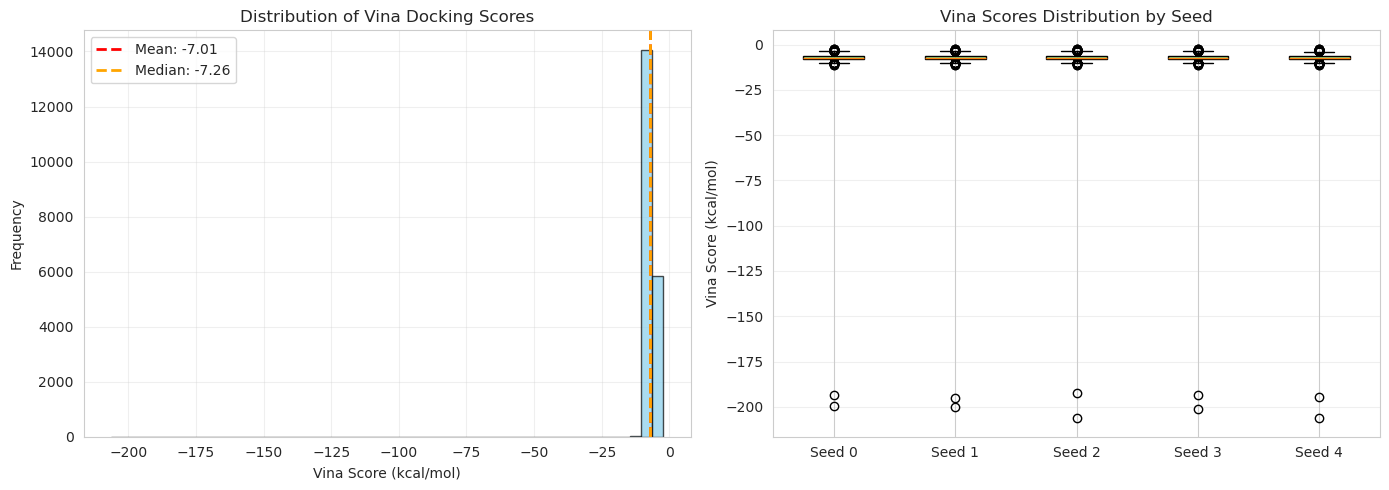


Vina Score Statistics:
  Best (lowest): -206.32 kcal/mol
  Worst (highest): -2.35 kcal/mol
  Mean: -7.01 ± 4.48 kcal/mol
  Median: -7.26 kcal/mol


In [10]:
# Filter valid vina scores
valid_scores = df[df['vina_score'].notna()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of vina scores
axes[0].hist(valid_scores['vina_score'], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(valid_scores['vina_score'].mean(), color='red', linestyle='--', linewidth=2,
                label=f'Mean: {valid_scores["vina_score"].mean():.2f}')
axes[0].axvline(valid_scores['vina_score'].median(), color='orange', linestyle='--', linewidth=2,
                label=f'Median: {valid_scores["vina_score"].median():.2f}')
axes[0].set_xlabel('Vina Score (kcal/mol)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Vina Docking Scores')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Box plot by seed
seed_scores = [valid_scores[valid_scores['seed'] == s]['vina_score'].values for s in range(5)]
bp = axes[1].boxplot(seed_scores, labels=[f'Seed {i}' for i in range(5)], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
axes[1].set_ylabel('Vina Score (kcal/mol)')
axes[1].set_title('Vina Scores Distribution by Seed')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig(plot_dir / 'vina_score_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nVina Score Statistics:")
print(f"  Best (lowest): {valid_scores['vina_score'].min():.2f} kcal/mol")
print(f"  Worst (highest): {valid_scores['vina_score'].max():.2f} kcal/mol")
print(f"  Mean: {valid_scores['vina_score'].mean():.2f} ± {valid_scores['vina_score'].std():.2f} kcal/mol")
print(f"  Median: {valid_scores['vina_score'].median():.2f} kcal/mol")

## 2. Ligand COM Distance Distribution

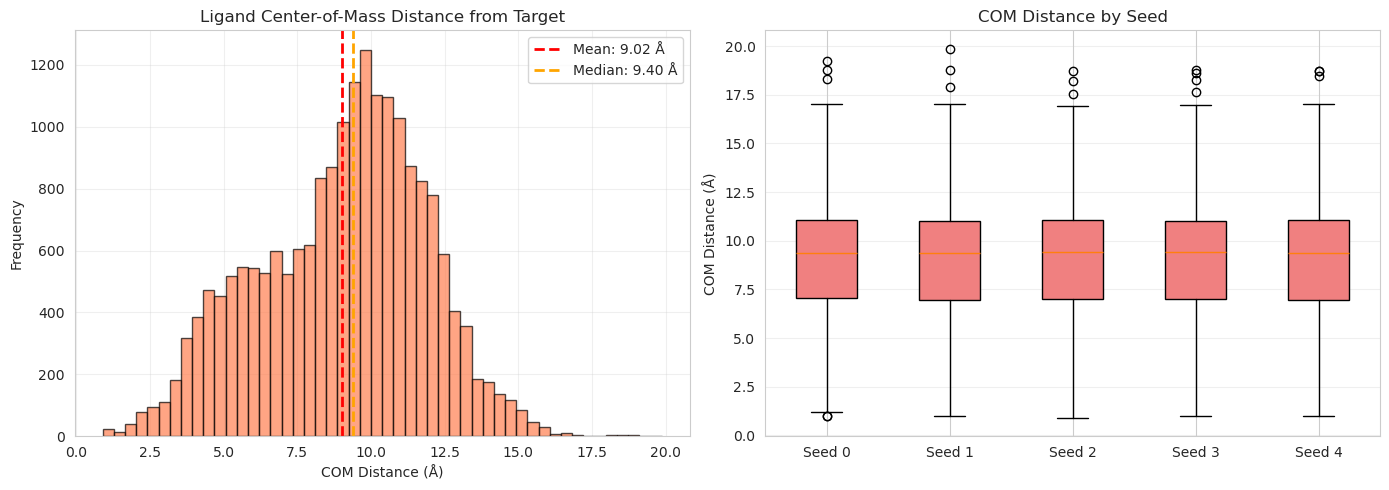


Ligand COM Distance Statistics:
  Closest: 0.90 Å
  Farthest: 19.86 Å
  Mean: 9.02 ± 2.84 Å
  Median: 9.40 Å


In [11]:
# Filter valid COM distances
valid_com = df[df['ligand_com_distance'].notna()]

if len(valid_com) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of COM distances
    axes[0].hist(valid_com['ligand_com_distance'], bins=50, edgecolor='black', alpha=0.7, color='coral')
    axes[0].axvline(valid_com['ligand_com_distance'].mean(), color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {valid_com["ligand_com_distance"].mean():.2f} Å')
    axes[0].axvline(valid_com['ligand_com_distance'].median(), color='orange', linestyle='--', linewidth=2,
                    label=f'Median: {valid_com["ligand_com_distance"].median():.2f} Å')
    axes[0].set_xlabel('COM Distance (Å)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Ligand Center-of-Mass Distance from Target')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Box plot by seed
    seed_com = [valid_com[valid_com['seed'] == s]['ligand_com_distance'].values for s in range(5)]
    bp = axes[1].boxplot(seed_com, labels=[f'Seed {i}' for i in range(5)], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('lightcoral')
    axes[1].set_ylabel('COM Distance (Å)')
    axes[1].set_title('COM Distance by Seed')
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(plot_dir / 'ligand_com_distance.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nLigand COM Distance Statistics:")
    print(f"  Closest: {valid_com['ligand_com_distance'].min():.2f} Å")
    print(f"  Farthest: {valid_com['ligand_com_distance'].max():.2f} Å")
    print(f"  Mean: {valid_com['ligand_com_distance'].mean():.2f} ± {valid_com['ligand_com_distance'].std():.2f} Å")
    print(f"  Median: {valid_com['ligand_com_distance'].median():.2f} Å")
else:
    print("No valid COM distance data available")

## 3. Ligand RMSD Among Seeds

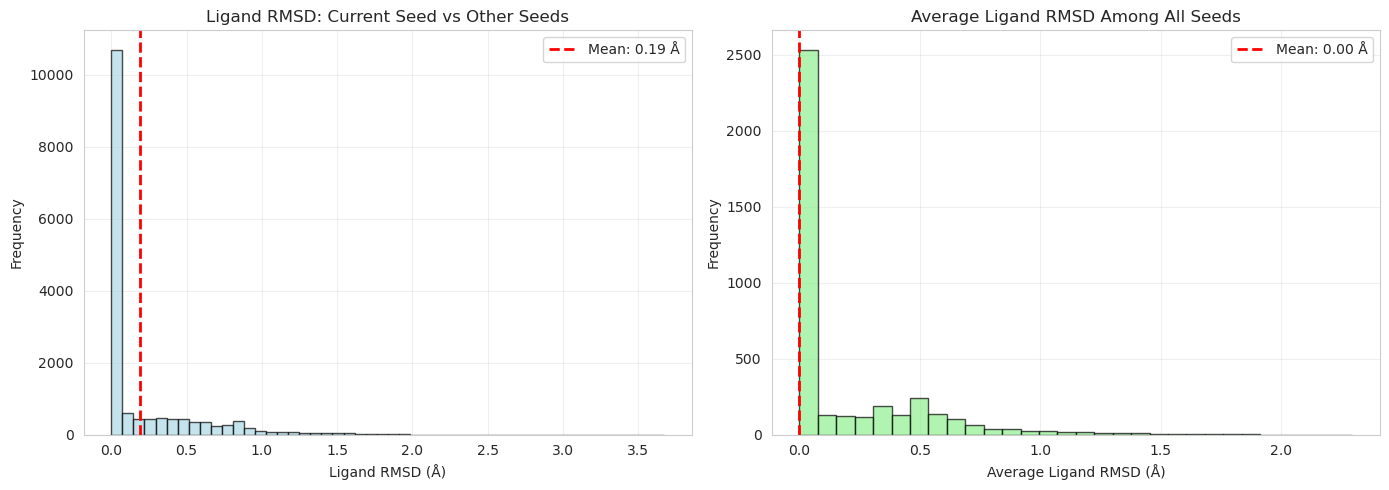


Ligand RMSD Statistics (Current vs Other Seeds):
  Min: 0.00 Å
  Max: 3.67 Å
  Mean: 0.19 ± 0.35 Å

Average Ligand RMSD Among All Seeds: 0.00 Å


In [12]:
# Current seed RMSD
valid_rmsd_current = df[df['ligand_rmsd_current_seed'].notna()]

if len(valid_rmsd_current) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of current seed RMSD
    axes[0].hist(valid_rmsd_current['ligand_rmsd_current_seed'], bins=50, edgecolor='black', alpha=0.7, color='lightblue')
    axes[0].axvline(valid_rmsd_current['ligand_rmsd_current_seed'].mean(), color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {valid_rmsd_current["ligand_rmsd_current_seed"].mean():.2f} Å')
    axes[0].set_xlabel('Ligand RMSD (Å)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Ligand RMSD: Current Seed vs Other Seeds')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    
    # Average RMSD among all seeds
    valid_rmsd_avg = df[df['ligand_rmsd_avg_all_seeds'].notna()]
    if len(valid_rmsd_avg) > 0:
        axes[1].hist(valid_rmsd_avg['ligand_rmsd_avg_all_seeds'].unique(), bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
        axes[1].axvline(valid_rmsd_avg['ligand_rmsd_avg_all_seeds'].iloc[0], color='red', linestyle='--', linewidth=2,
                        label=f'Mean: {valid_rmsd_avg["ligand_rmsd_avg_all_seeds"].iloc[0]:.2f} Å')
        axes[1].set_xlabel('Average Ligand RMSD (Å)')
        axes[1].set_ylabel('Frequency')
        axes[1].set_title('Average Ligand RMSD Among All Seeds')
        axes[1].legend()
        axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(plot_dir / 'ligand_rmsd_among_seeds.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nLigand RMSD Statistics (Current vs Other Seeds):")
    print(f"  Min: {valid_rmsd_current['ligand_rmsd_current_seed'].min():.2f} Å")
    print(f"  Max: {valid_rmsd_current['ligand_rmsd_current_seed'].max():.2f} Å")
    print(f"  Mean: {valid_rmsd_current['ligand_rmsd_current_seed'].mean():.2f} ± {valid_rmsd_current['ligand_rmsd_current_seed'].std():.2f} Å")
    
    if len(valid_rmsd_avg) > 0:
        print(f"\nAverage Ligand RMSD Among All Seeds: {valid_rmsd_avg['ligand_rmsd_avg_all_seeds'].iloc[0]:.2f} Å")
else:
    print("No valid RMSD among seeds data available")

## 4. IFP Similarity Distribution

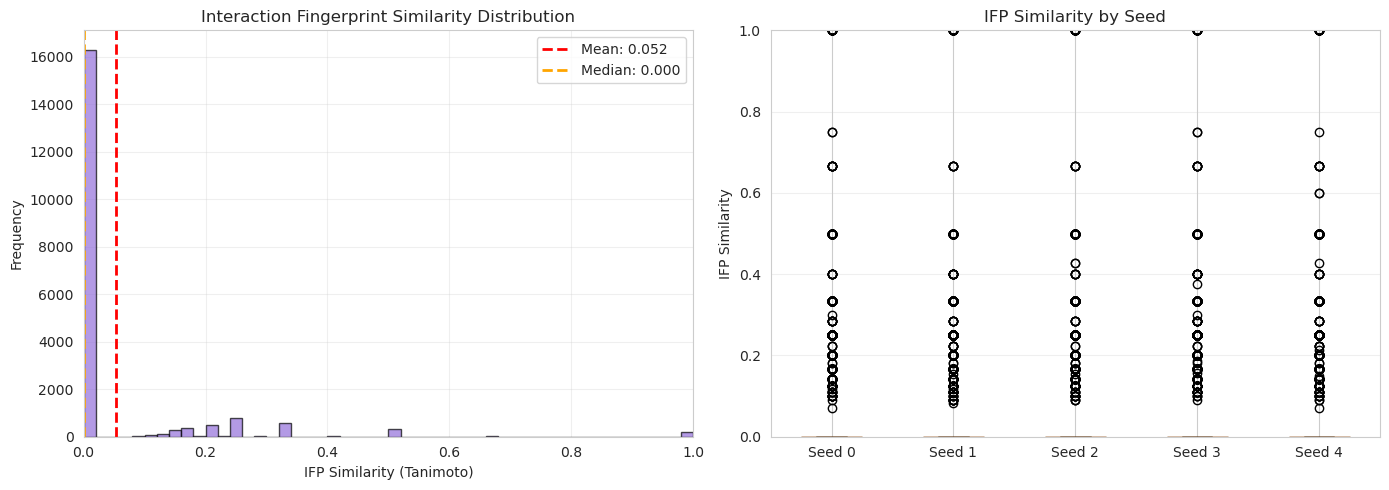


IFP Similarity Statistics:
  Min: 0.000
  Max: 1.000
  Mean: 0.052 ± 0.145
  Median: 0.000


In [13]:
# IFP Similarity
valid_ifp = df[df['ligand_ifp_similarity'].notna()]

if len(valid_ifp) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogram of IFP similarity
    axes[0].hist(valid_ifp['ligand_ifp_similarity'], bins=50, edgecolor='black', alpha=0.7, color='mediumpurple')
    axes[0].axvline(valid_ifp['ligand_ifp_similarity'].mean(), color='red', linestyle='--', linewidth=2,
                    label=f'Mean: {valid_ifp["ligand_ifp_similarity"].mean():.3f}')
    axes[0].axvline(valid_ifp['ligand_ifp_similarity'].median(), color='orange', linestyle='--', linewidth=2,
                    label=f'Median: {valid_ifp["ligand_ifp_similarity"].median():.3f}')
    axes[0].set_xlabel('IFP Similarity (Tanimoto)')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Interaction Fingerprint Similarity Distribution')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_xlim(0, 1)
    
    # Box plot by seed
    seed_ifp = [valid_ifp[valid_ifp['seed'] == s]['ligand_ifp_similarity'].values for s in range(5)]
    bp = axes[1].boxplot(seed_ifp, labels=[f'Seed {i}' for i in range(5)], patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('plum')
    axes[1].set_ylabel('IFP Similarity')
    axes[1].set_title('IFP Similarity by Seed')
    axes[1].set_ylim(0, 1)
    axes[1].grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig(plot_dir / 'ifp_similarity.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nIFP Similarity Statistics:")
    print(f"  Min: {valid_ifp['ligand_ifp_similarity'].min():.3f}")
    print(f"  Max: {valid_ifp['ligand_ifp_similarity'].max():.3f}")
    print(f"  Mean: {valid_ifp['ligand_ifp_similarity'].mean():.3f} ± {valid_ifp['ligand_ifp_similarity'].std():.3f}")
    print(f"  Median: {valid_ifp['ligand_ifp_similarity'].median():.3f}")
else:
    print("No valid IFP similarity data available")

## 5. Vina Score vs Ligand Metrics

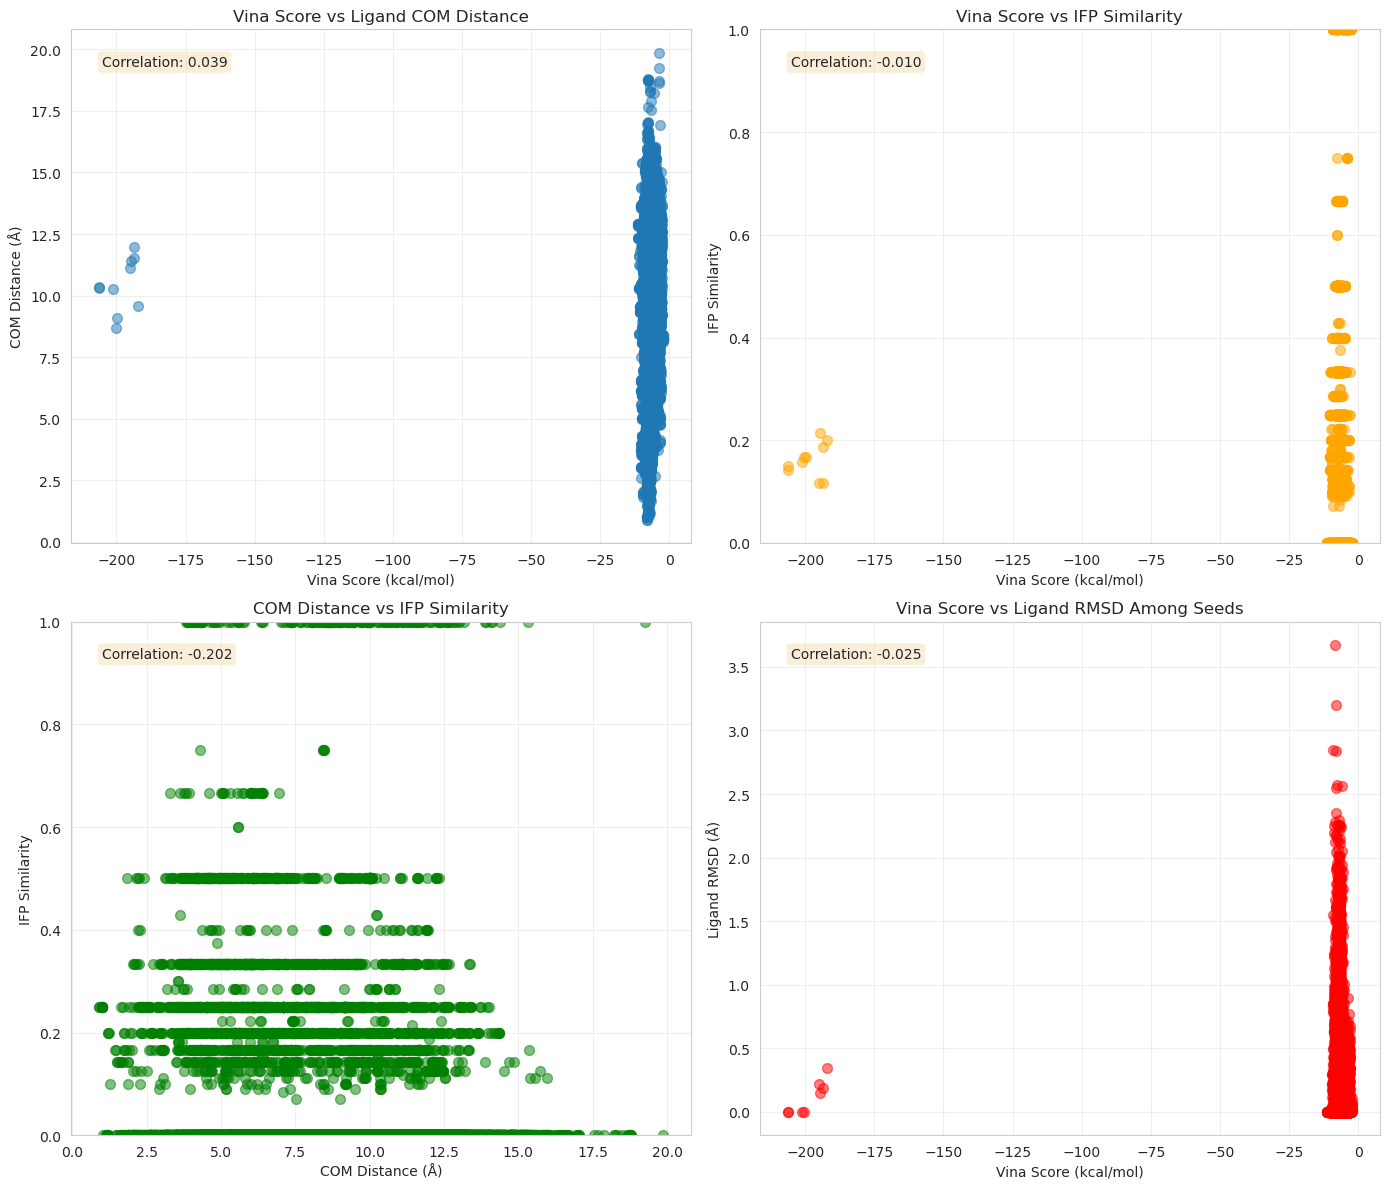

In [14]:
# Prepare data for scatter plots
plot_data = df[(df['vina_score'].notna())].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Vina Score vs COM Distance
valid_com_plot = plot_data[plot_data['ligand_com_distance'].notna()]
if len(valid_com_plot) > 0:
    axes[0, 0].scatter(plot_data['vina_score'], plot_data['ligand_com_distance'], alpha=0.5, s=50)
    axes[0, 0].set_xlabel('Vina Score (kcal/mol)')
    axes[0, 0].set_ylabel('COM Distance (Å)')
    axes[0, 0].set_title('Vina Score vs Ligand COM Distance')
    axes[0, 0].grid(alpha=0.3)
    # Calculate correlation
    corr = valid_com_plot['vina_score'].corr(valid_com_plot['ligand_com_distance'])
    axes[0, 0].text(0.05, 0.95, f'Correlation: {corr:.3f}', 
                    transform=axes[0, 0].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Vina Score vs IFP Similarity
valid_ifp_plot = plot_data[plot_data['ligand_ifp_similarity'].notna()]
if len(valid_ifp_plot) > 0:
    axes[0, 1].scatter(plot_data['vina_score'], plot_data['ligand_ifp_similarity'], alpha=0.5, s=50, color='orange')
    axes[0, 1].set_xlabel('Vina Score (kcal/mol)')
    axes[0, 1].set_ylabel('IFP Similarity')
    axes[0, 1].set_title('Vina Score vs IFP Similarity')
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].set_ylim(0, 1)
    # Calculate correlation
    corr = valid_ifp_plot['vina_score'].corr(valid_ifp_plot['ligand_ifp_similarity'])
    axes[0, 1].text(0.05, 0.95, f'Correlation: {corr:.3f}',
                    transform=axes[0, 1].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# COM Distance vs IFP Similarity
valid_both = plot_data[(plot_data['ligand_com_distance'].notna()) & 
                        (plot_data['ligand_ifp_similarity'].notna())]
if len(valid_both) > 0:
    axes[1, 0].scatter(valid_both['ligand_com_distance'], valid_both['ligand_ifp_similarity'], 
                       alpha=0.5, s=50, color='green')
    axes[1, 0].set_xlabel('COM Distance (Å)')
    axes[1, 0].set_ylabel('IFP Similarity')
    axes[1, 0].set_title('COM Distance vs IFP Similarity')
    axes[1, 0].grid(alpha=0.3)
    axes[1, 0].set_ylim(0, 1)
    # Calculate correlation
    corr = valid_both['ligand_com_distance'].corr(valid_both['ligand_ifp_similarity'])
    axes[1, 0].text(0.05, 0.95, f'Correlation: {corr:.3f}',
                    transform=axes[1, 0].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Vina Score vs Ligand RMSD
valid_rmsd_plot = plot_data[plot_data['ligand_rmsd_current_seed'].notna()]
if len(valid_rmsd_plot) > 0:
    axes[1, 1].scatter(plot_data['vina_score'], plot_data['ligand_rmsd_current_seed'], 
                       alpha=0.5, s=50, color='red')
    axes[1, 1].set_xlabel('Vina Score (kcal/mol)')
    axes[1, 1].set_ylabel('Ligand RMSD (Å)')
    axes[1, 1].set_title('Vina Score vs Ligand RMSD Among Seeds')
    axes[1, 1].grid(alpha=0.3)
    # Calculate correlation
    corr = valid_rmsd_plot['vina_score'].corr(valid_rmsd_plot['ligand_rmsd_current_seed'])
    axes[1, 1].text(0.05, 0.95, f'Correlation: {corr:.3f}',
                    transform=axes[1, 1].transAxes, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(plot_dir / 'vina_metrics_scatter.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Per-Complex Analysis

In [15]:
# Group by complex and calculate statistics
complex_stats = df.groupby('complex_id').agg({
    'vina_score': ['mean', 'std', 'min', 'max'],
    'ligand_com_distance': ['mean', 'std'],
    'ligand_ifp_similarity': ['mean', 'std'],
    'ligand_rmsd_current_seed': ['mean', 'std'],
    'complex_pdb_saved': 'sum'
}).round(3)

print("\nPer-complex statistics (first 15):")
print(complex_stats.head(15))

# Save per-complex stats
complex_stats.to_csv(plot_dir / 'vina_per_complex_stats.csv')
print("\nSaved per-complex statistics to vina_per_complex_stats.csv")


Per-complex statistics (first 15):
           vina_score                      ligand_com_distance         \
                 mean    std    min    max                mean    std   
complex_id                                                              
81             -7.799  0.219 -8.092 -7.405               5.809  3.910   
82             -7.673  0.229 -7.946 -7.307               6.382  3.364   
83             -8.073  0.304 -8.439 -7.571               6.968  3.771   
84             -8.090  0.294 -8.439 -7.707               6.977  3.767   
85             -8.053  0.383 -8.521 -7.522               7.775  3.346   
86             -8.052  0.393 -8.521 -7.522               7.767  3.349   
87             -8.143  0.350 -8.540 -7.538               7.750  3.383   
88             -8.161  0.314 -8.540 -7.597               7.779  3.366   
89             -8.128  0.157 -8.319 -7.904               9.659  3.775   
130            -7.213  0.362 -7.743 -6.664               6.836  2.410   
214            

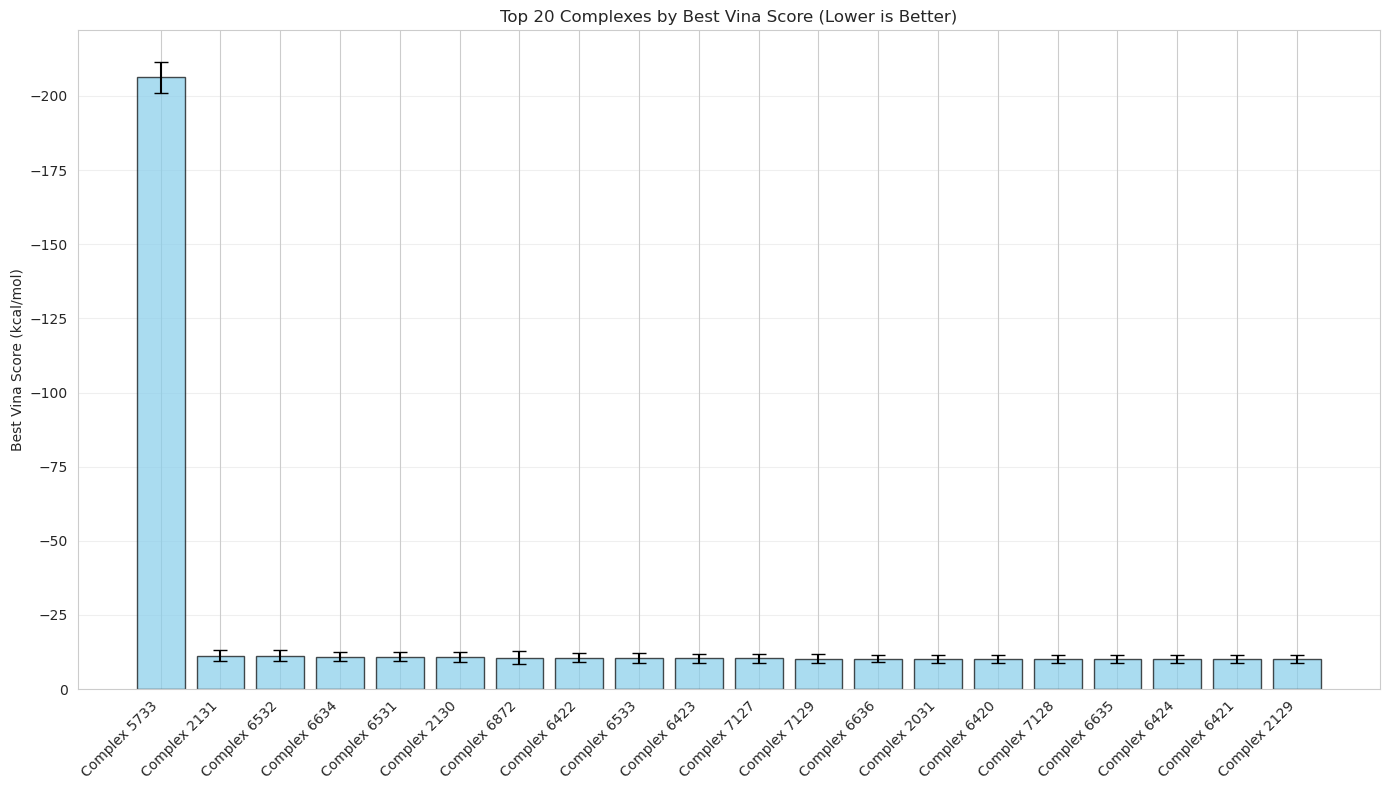

In [16]:
# Plot top 20 complexes by best vina score
top_complexes = complex_stats.nsmallest(20, ('vina_score', 'min'))

fig, ax = plt.subplots(figsize=(14, 8))
x = range(len(top_complexes))
y = top_complexes[('vina_score', 'min')].values
yerr = top_complexes[('vina_score', 'std')].values

ax.bar(x, y, yerr=yerr, capsize=5, alpha=0.7, color='skyblue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels([f'Complex {idx}' for idx in top_complexes.index], rotation=45, ha='right')
ax.set_ylabel('Best Vina Score (kcal/mol)')
ax.set_title('Top 20 Complexes by Best Vina Score (Lower is Better)')
ax.grid(axis='y', alpha=0.3)
ax.invert_yaxis()  # Lower energy is better

plt.tight_layout()
plt.savefig(plot_dir / 'top_complexes_vina.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Seed-wise Comparison

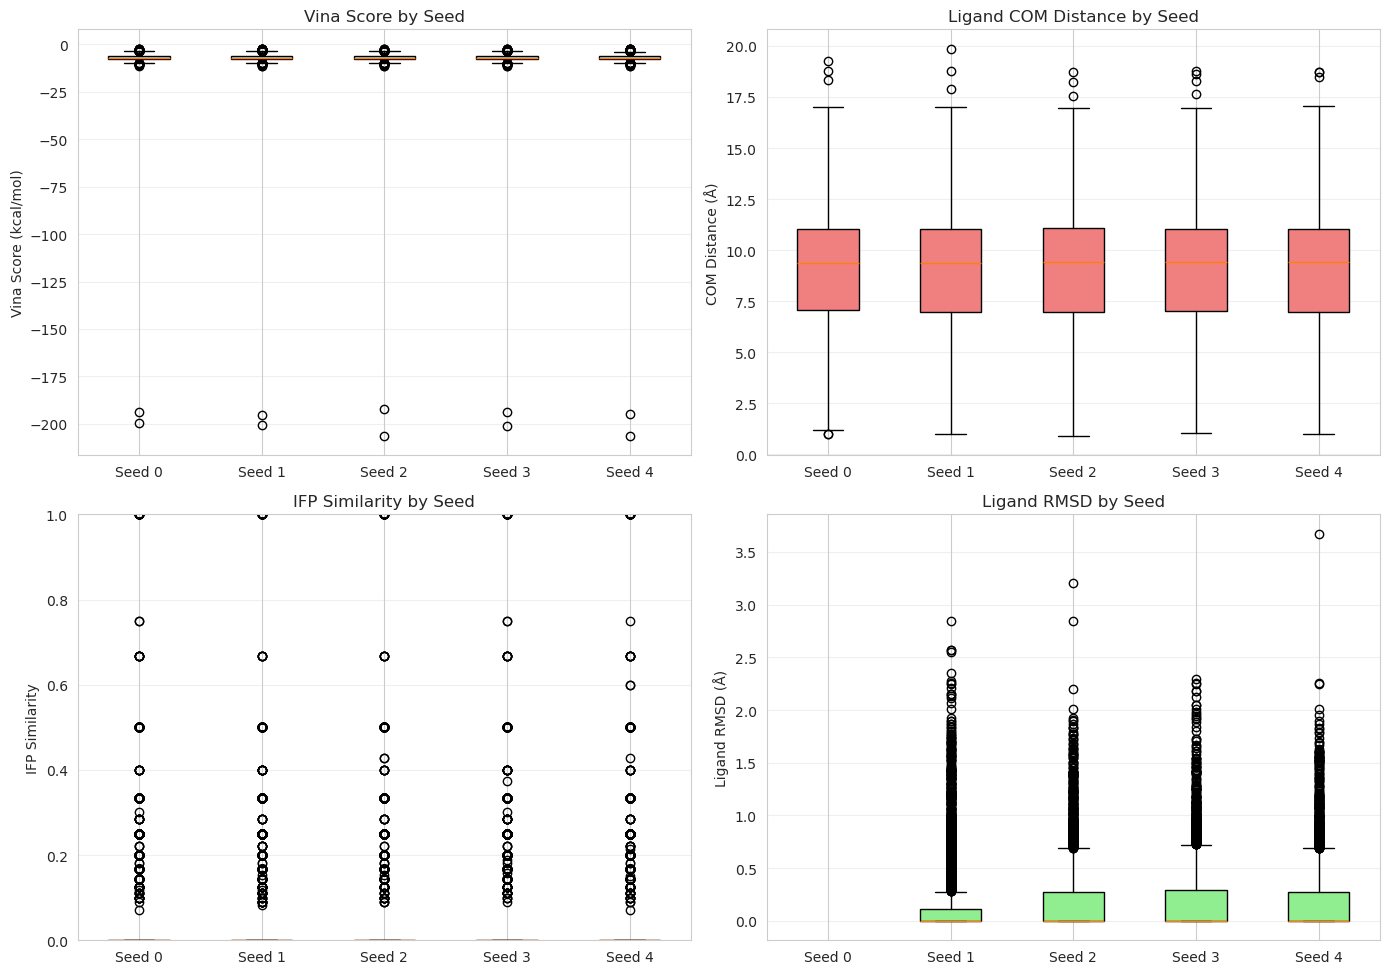

In [17]:
# Box plots by seed
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Vina Score by seed
seed_scores = [df[df['seed'] == s]['vina_score'].dropna().values for s in range(5)]
bp = axes[0, 0].boxplot(seed_scores, labels=[f'Seed {i}' for i in range(5)], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightblue')
axes[0, 0].set_ylabel('Vina Score (kcal/mol)')
axes[0, 0].set_title('Vina Score by Seed')
axes[0, 0].grid(alpha=0.3, axis='y')

# COM Distance by seed
seed_com = [df[df['seed'] == s]['ligand_com_distance'].dropna().values for s in range(5)]
bp = axes[0, 1].boxplot(seed_com, labels=[f'Seed {i}' for i in range(5)], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightcoral')
axes[0, 1].set_ylabel('COM Distance (Å)')
axes[0, 1].set_title('Ligand COM Distance by Seed')
axes[0, 1].grid(alpha=0.3, axis='y')

# IFP Similarity by seed
seed_ifp = [df[df['seed'] == s]['ligand_ifp_similarity'].dropna().values for s in range(5)]
bp = axes[1, 0].boxplot(seed_ifp, labels=[f'Seed {i}' for i in range(5)], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('plum')
axes[1, 0].set_ylabel('IFP Similarity')
axes[1, 0].set_title('IFP Similarity by Seed')
axes[1, 0].set_ylim(0, 1)
axes[1, 0].grid(alpha=0.3, axis='y')

# Ligand RMSD by seed
seed_rmsd = [df[df['seed'] == s]['ligand_rmsd_current_seed'].dropna().values for s in range(5)]
bp = axes[1, 1].boxplot(seed_rmsd, labels=[f'Seed {i}' for i in range(5)], patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('lightgreen')
axes[1, 1].set_ylabel('Ligand RMSD (Å)')
axes[1, 1].set_title('Ligand RMSD by Seed')
axes[1, 1].grid(alpha=0.3, axis='y')

plt.suptitle('')  # Remove default title
plt.tight_layout()
plt.savefig(plot_dir / 'seed_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Success Rate and Quality Metrics

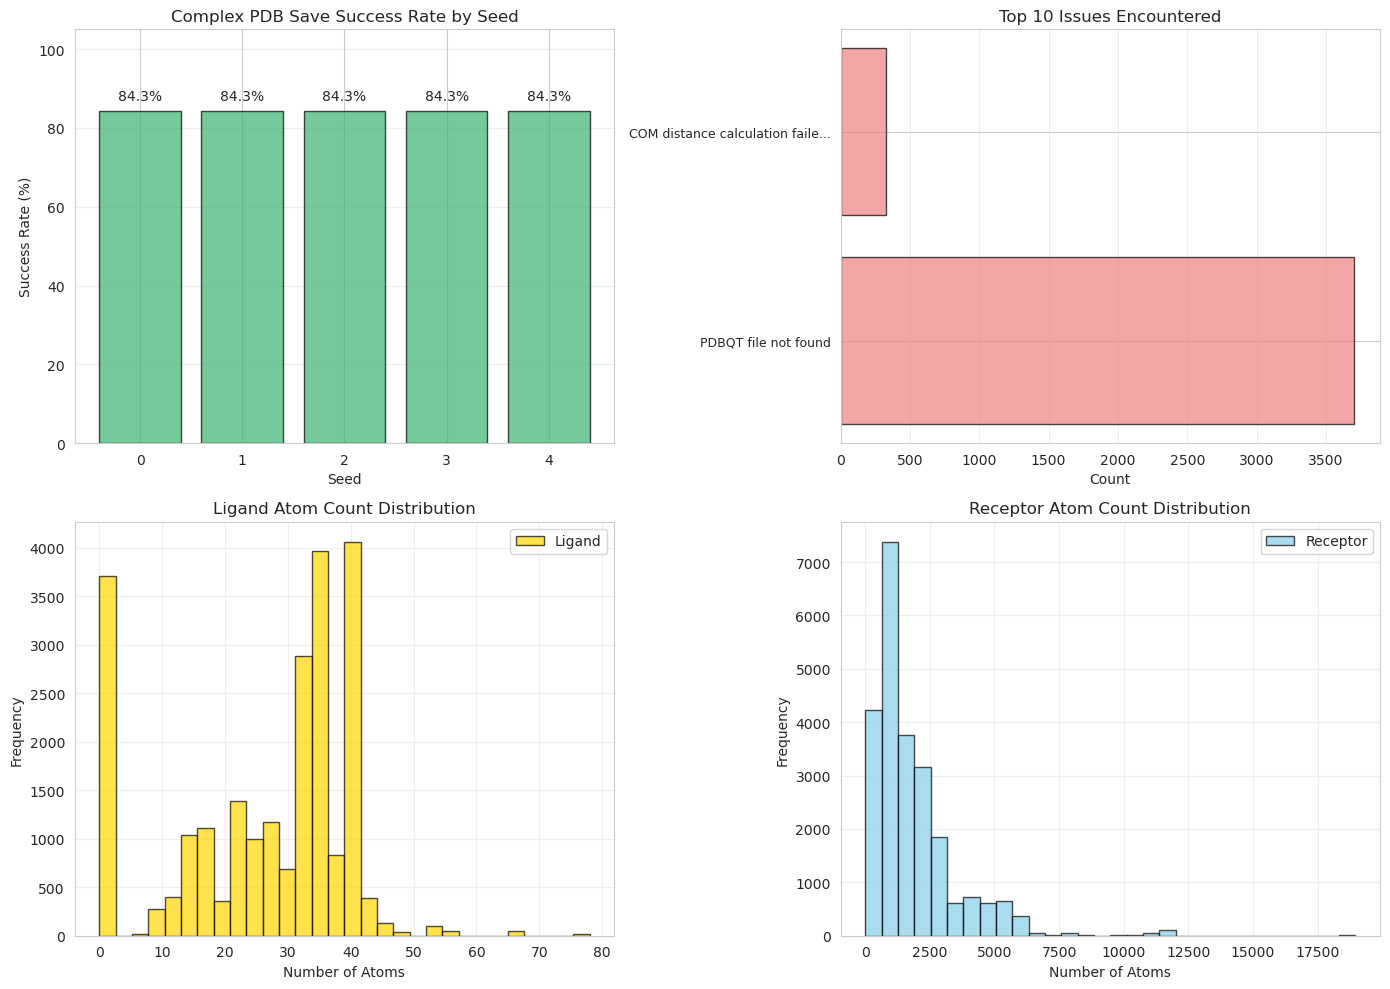


Success Rate:
  Overall PDB saves: 19955/23660 (84.3%)

Top Issues:
  PDBQT file not found: 3705
  COM distance calculation failed; Target IFP calculation failed: 325


In [18]:
# Calculate success metrics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Success rate of complex PDB saves
success_counts = df['complex_pdb_saved'].astype(int).value_counts()
success_rates = df.groupby('seed')['complex_pdb_saved'].apply(lambda x: (x.sum() / len(x)) * 100)

axes[0, 0].bar(success_rates.index, success_rates.values, color='mediumseagreen', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Seed')
axes[0, 0].set_ylabel('Success Rate (%)')
axes[0, 0].set_title('Complex PDB Save Success Rate by Seed')
axes[0, 0].set_ylim(0, 105)
axes[0, 0].grid(alpha=0.3, axis='y')
# Add percentage labels
for i, v in enumerate(success_rates.values):
    axes[0, 0].text(i, v + 2, f'{v:.1f}%', ha='center', va='bottom')

# Count of issues
issues_df = df[df['notes'] != 'OK']
issue_counts = issues_df['notes'].value_counts().head(10)

axes[0, 1].barh(range(len(issue_counts)), issue_counts.values, color='lightcoral', edgecolor='black', alpha=0.7)
axes[0, 1].set_yticks(range(len(issue_counts)))
axes[0, 1].set_yticklabels([s[:30] + '...' if len(s) > 30 else s for s in issue_counts.index], fontsize=9)
axes[0, 1].set_xlabel('Count')
axes[0, 1].set_title('Top 10 Issues Encountered')
axes[0, 1].grid(alpha=0.3, axis='x')

# Number of atoms distribution
axes[1, 0].hist(df['num_ligand_atoms'], bins=30, edgecolor='black', alpha=0.7, color='gold', label='Ligand')
axes[1, 0].set_xlabel('Number of Atoms')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Ligand Atom Count Distribution')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].hist(df['num_receptor_atoms'], bins=30, edgecolor='black', alpha=0.7, color='skyblue', label='Receptor')
axes[1, 1].set_xlabel('Number of Atoms')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_title('Receptor Atom Count Distribution')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(plot_dir / 'success_and_quality_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSuccess Rate:")
print(f"  Overall PDB saves: {df['complex_pdb_saved'].sum()}/{len(df)} ({(df['complex_pdb_saved'].sum()/len(df))*100:.1f}%)")
print(f"\nTop Issues:")
for issue, count in issue_counts.items():
    print(f"  {issue}: {count}")

## 9. Summary Report

In [19]:
print("="*70)
print("VINA POST-PROCESSING SUMMARY REPORT")
print("="*70)

print(f"\n--- Dataset Overview ---")
print(f"Total number of docked structures: {len(df)}")
print(f"Number of unique complexes: {df['complex_id'].nunique()}")
print(f"Number of unique ligands: {df['ligand_het_id'].nunique()}")
print(f"Number of seeds per complex: 5")
print(f"Successful PDB saves: {df['complex_pdb_saved'].sum()}/{len(df)} ({(df['complex_pdb_saved'].sum()/len(df))*100:.1f}%)")

# Vina scores
valid_scores = df[df['vina_score'].notna()]
print(f"\n--- Vina Docking Scores ---")
print(f"Valid scores: {len(valid_scores)}/{len(df)}")
if len(valid_scores) > 0:
    print(f"  Best (lowest): {valid_scores['vina_score'].min():.2f} kcal/mol")
    print(f"  Worst (highest): {valid_scores['vina_score'].max():.2f} kcal/mol")
    print(f"  Mean: {valid_scores['vina_score'].mean():.2f} ± {valid_scores['vina_score'].std():.2f} kcal/mol")
    print(f"  Median: {valid_scores['vina_score'].median():.2f} kcal/mol")

# COM distances
valid_com = df[df['ligand_com_distance'].notna()]
print(f"\n--- Ligand COM Distance ---")
print(f"Valid measurements: {len(valid_com)}/{len(df)}")
if len(valid_com) > 0:
    print(f"  Closest: {valid_com['ligand_com_distance'].min():.2f} Å")
    print(f"  Farthest: {valid_com['ligand_com_distance'].max():.2f} Å")
    print(f"  Mean: {valid_com['ligand_com_distance'].mean():.2f} ± {valid_com['ligand_com_distance'].std():.2f} Å")
    print(f"  Median: {valid_com['ligand_com_distance'].median():.2f} Å")

# IFP similarities
valid_ifp = df[df['ligand_ifp_similarity'].notna()]
print(f"\n--- Interaction Fingerprint Similarity ---")
print(f"Valid measurements: {len(valid_ifp)}/{len(df)}")
if len(valid_ifp) > 0:
    print(f"  Min: {valid_ifp['ligand_ifp_similarity'].min():.3f}")
    print(f"  Max: {valid_ifp['ligand_ifp_similarity'].max():.3f}")
    print(f"  Mean: {valid_ifp['ligand_ifp_similarity'].mean():.3f} ± {valid_ifp['ligand_ifp_similarity'].std():.3f}")
    print(f"  Median: {valid_ifp['ligand_ifp_similarity'].median():.3f}")
    # Count high similarity (>0.7)
    high_sim = len(valid_ifp[valid_ifp['ligand_ifp_similarity'] > 0.7])
    print(f"  High similarity (>0.7): {high_sim}/{len(valid_ifp)} ({(high_sim/len(valid_ifp))*100:.1f}%)")

# RMSD among seeds
valid_rmsd = df[df['ligand_rmsd_current_seed'].notna()]
print(f"\n--- Ligand RMSD Among Seeds ---")
print(f"Valid measurements: {len(valid_rmsd)}/{len(df)}")
if len(valid_rmsd) > 0:
    print(f"  Min: {valid_rmsd['ligand_rmsd_current_seed'].min():.2f} Å")
    print(f"  Max: {valid_rmsd['ligand_rmsd_current_seed'].max():.2f} Å")
    print(f"  Mean: {valid_rmsd['ligand_rmsd_current_seed'].mean():.2f} ± {valid_rmsd['ligand_rmsd_current_seed'].std():.2f} Å")

# Ligand types
print(f"\n--- Ligand Types (HET IDs) ---")
het_counts = df['ligand_het_id'].value_counts().head(10)
for het_id, count in het_counts.items():
    print(f"  {het_id}: {count} structures")

# Issues summary
issues = df[df['notes'] != 'OK']
print(f"\n--- Data Quality ---")
print(f"Records with issues: {len(issues)}/{len(df)} ({(len(issues)/len(df))*100:.1f}%)")
if len(issues) > 0:
    issue_counts = issues['notes'].value_counts()
    print(f"  Top issues:")
    for issue, count in issue_counts.head(5).items():
        print(f"    {issue}: {count}")

print("\n" + "="*70)

VINA POST-PROCESSING SUMMARY REPORT

--- Dataset Overview ---
Total number of docked structures: 23660
Number of unique complexes: 1578
Number of unique ligands: 1352
Number of seeds per complex: 5
Successful PDB saves: 19955/23660 (84.3%)

--- Vina Docking Scores ---
Valid scores: 19955/23660
  Best (lowest): -206.32 kcal/mol
  Worst (highest): -2.35 kcal/mol
  Mean: -7.01 ± 4.48 kcal/mol
  Median: -7.26 kcal/mol

--- Ligand COM Distance ---
Valid measurements: 19630/23660
  Closest: 0.90 Å
  Farthest: 19.86 Å
  Mean: 9.02 ± 2.84 Å
  Median: 9.40 Å

--- Interaction Fingerprint Similarity ---
Valid measurements: 19630/23660
  Min: 0.000
  Max: 1.000
  Mean: 0.052 ± 0.145
  Median: 0.000
  High similarity (>0.7): 215/19630 (1.1%)

--- Ligand RMSD Among Seeds ---
Valid measurements: 15964/23660
  Min: 0.00 Å
  Max: 3.67 Å
  Mean: 0.19 ± 0.35 Å

--- Ligand Types (HET IDs) ---
  1N1: 165 structures
  LQ5: 150 structures
  AQ4: 135 structures
  JIN: 105 structures
  0WM: 105 structures
  2Y

In [20]:
# Export summary statistics to text file
with open(plot_dir / 'vina_summary_report.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("VINA POST-PROCESSING SUMMARY REPORT\n")
    f.write("="*70 + "\n\n")
    
    f.write(f"--- Dataset Overview ---\n")
    f.write(f"Total number of docked structures: {len(df)}\n")
    f.write(f"Number of unique complexes: {df['complex_id'].nunique()}\n")
    f.write(f"Number of unique ligands: {df['ligand_het_id'].nunique()}\n")
    f.write(f"Successful PDB saves: {df['complex_pdb_saved'].sum()}/{len(df)} ({(df['complex_pdb_saved'].sum()/len(df))*100:.1f}%)\n\n")
    
    if len(valid_scores) > 0:
        f.write(f"--- Vina Docking Scores ---\n")
        f.write(f"Best (lowest): {valid_scores['vina_score'].min():.2f} kcal/mol\n")
        f.write(f"Worst (highest): {valid_scores['vina_score'].max():.2f} kcal/mol\n")
        f.write(f"Mean: {valid_scores['vina_score'].mean():.2f} ± {valid_scores['vina_score'].std():.2f} kcal/mol\n")
        f.write(f"Median: {valid_scores['vina_score'].median():.2f} kcal/mol\n\n")
    
    if len(valid_com) > 0:
        f.write(f"--- Ligand COM Distance ---\n")
        f.write(f"Closest: {valid_com['ligand_com_distance'].min():.2f} Å\n")
        f.write(f"Farthest: {valid_com['ligand_com_distance'].max():.2f} Å\n")
        f.write(f"Mean: {valid_com['ligand_com_distance'].mean():.2f} ± {valid_com['ligand_com_distance'].std():.2f} Å\n")
        f.write(f"Median: {valid_com['ligand_com_distance'].median():.2f} Å\n\n")
    
    if len(valid_ifp) > 0:
        f.write(f"--- Interaction Fingerprint Similarity ---\n")
        f.write(f"Mean: {valid_ifp['ligand_ifp_similarity'].mean():.3f} ± {valid_ifp['ligand_ifp_similarity'].std():.3f}\n")
        f.write(f"Median: {valid_ifp['ligand_ifp_similarity'].median():.3f}\n")
        high_sim = len(valid_ifp[valid_ifp['ligand_ifp_similarity'] > 0.7])
        f.write(f"High similarity (>0.7): {high_sim}/{len(valid_ifp)} ({(high_sim/len(valid_ifp))*100:.1f}%)\n\n")
    
    f.write("="*70 + "\n")

print(f"Summary report saved to {plot_dir / 'vina_summary_report.txt'}")

Summary report saved to /scratch/yunmin/data/graph/lmpnn/bdb_pdb/off_inputs/eval/vina_plots/vina_summary_report.txt
